# 5 — Bancada de exploração

Notebook de trabalho: a célula abaixo deixa tudo carregado e pronto. Diferente dos notebooks
1–4, aqui nada é definitivo — é onde testamos ideias antes de decidir o que vira análise.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

from src.utils import load_config
from src import antenna

CIDADE = "campinas"
config = load_config(CIDADE)
config["spatial"]["download_basemap"] = True

edges_antenna = pd.read_parquet(ROOT / config["data"]["edges_antenna_path"])
antennas = pd.read_parquet(ROOT / config["data"]["antennas_path"])

net   = antenna.build(edges_antenna, antennas, config)
nodes = net.nodes          # uma linha por região
flows = net.flows          # uma linha por par de regiões conectado
G     = net.G              # grafo não-direcionado ponderado
D     = net.D              # versão dirigida
B     = net.backbone       # backbone por filtro de disparidade

cm = antenna.build_contact_matrix(edges_antenna, nodes)   # matriz do paper
K, J = cm.K, cm.J

print(f"{net.n_antennas} regiões | {G.number_of_edges():,} fluxos | {nodes['n_users'].sum():,} moradores")
print(f"objetos prontos: nodes, flows, G, D, B, cm, K, J")

145 regiões | 5,817 fluxos | 25,176 moradores
objetos prontos: nodes, flows, G, D, B, cm, K, J


## Atalhos úteis

Mapa temático de qualquer coluna de `nodes` (usa as células de Voronoi):

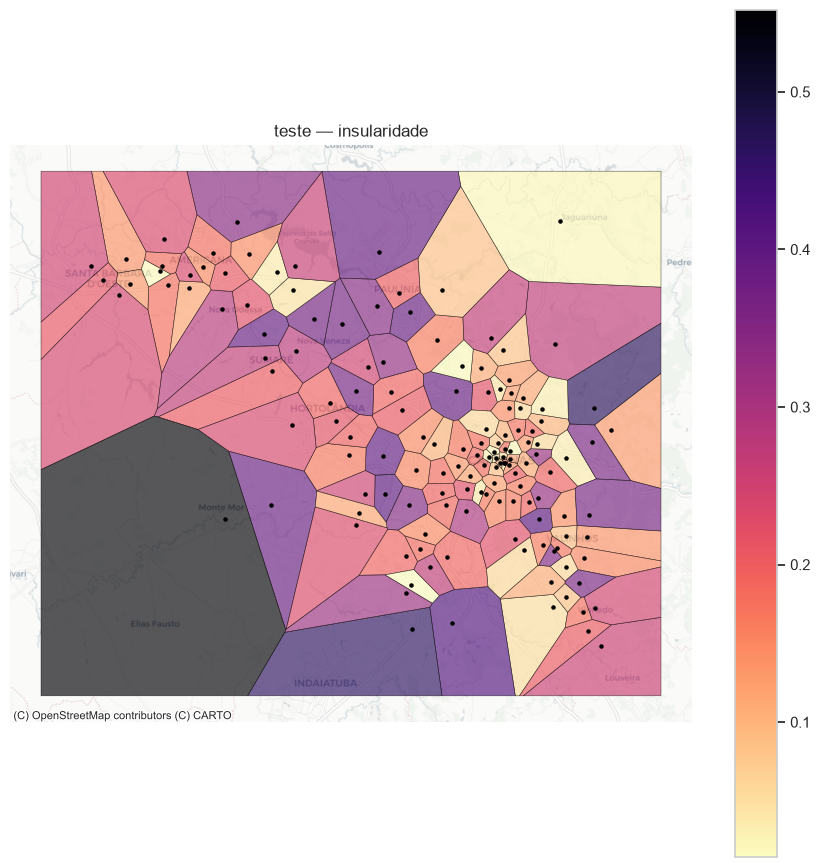

In [2]:
from src.boundary import load_boundary
from src.pipeline.spatial import _build_gdf, _build_voronoi, _add_basemap, _plot_boundary

gdf = _build_gdf(nodes)
limite = load_boundary(config, gdf.crs)   # None se o GeoJSON do limite não existir
vor = _build_voronoi(gdf, limite)


def mapa(coluna, titulo=None, cmap="viridis", categorico=False, centro=None, dados=None):
    """Pinta as regiões por uma coluna. `dados` permite passar uma Series indexada por antenna_id."""
    v = vor.copy()
    if dados is not None:
        v[coluna] = v["antenna_id"].map(dados)
    fig, ax = plt.subplots(figsize=(11, 11))
    kw = dict(column=coluna, cmap=cmap, legend=True, edgecolor="black",
              linewidth=0.4, alpha=0.65, ax=ax)
    if categorico:
        kw["categorical"] = True
    else:
        kw["legend_kwds"] = {"shrink": 0.55}   # sem isso a colorbar ocupa a figura inteira
        if centro is not None:
            s = v[coluna].dropna()
            span = max(abs(s.min() - centro), abs(s.max() - centro))
            kw.update(vmin=centro - span, vmax=centro + span)
    v.plot(**kw)
    gdf.plot(ax=ax, color="black", markersize=5)
    _plot_boundary(ax, limite, gdf.crs)
    _add_basemap(ax, config)
    ax.set_axis_off()
    ax.set_title(titulo or coluna)
    plt.show()


mapa("insularity", "teste — insularidade", cmap="magma_r")

## Espaço de trabalho

A partir daqui é livre.

In [3]:
nodes.head()

,antenna_id,residence_city,residence_quintile_state,residence_quintile_nation,lon,lat,n_users,calls_out,duration_out,calls_in,duration_in,calls_internal,duration_internal,calls_total,calls_external,insularity,net_balance,calls_per_user
0,22,Campinas,q5,q5,-47.04919,-22.93991,228,7550,10557.19,5914,11188.04,1919,3629.34,11545,9626,0.166219,0.121509,50.635965
1,52,Campinas,q4,q4,-47.01132,-22.80971,81,2347,5365.33,2010,3451.97,930,1145.17,3427,2497,0.271374,0.077347,42.308642
2,275,Campinas,q5,q5,-47.14177,-22.78256,117,3389,3833.74,3478,4619.79,1907,1830.03,4960,3053,0.384476,-0.012961,42.393162
3,312,Campinas,q1,q2,-47.15887,-22.84911,343,8687,17615.56,8666,17573.95,2826,3290.89,14527,11701,0.194534,0.001210,42.352770
4,321,Campinas,q5,q5,-47.07153,-22.84958,217,4934,7698.98,5091,7124.22,1796,2081.70,8229,6433,0.218253,-0.015661,37.921659


# Análises sobre J

Sete leituras da matriz de conexão. Todas usam `J` — a fração dos pares possíveis de usuários que
está de fato conectada entre duas regiões.

A ordem importa: as **macro-regiões** vêm primeiro, porque quase todas as figuras seguintes usam
elas para agrupar as antenas.

## 1. Comunidades de Louvain — as macro-regiões

### O que é uma macro-região

Um algoritmo de detecção de comunidades procura grupos de nós que trocam **mais entre si do que com
o resto da rede**. Aqui, os nós são antenas e o que elas trocam são chamadas. Uma macro-região é,
portanto:

> um conjunto de antenas cujos moradores se telefonam muito mais entre si do que com o restante da
> cidade.

Três coisas que ela **não** é:

- **Não é uma divisão administrativa.** Nada aqui vem de mapas oficiais, distritos ou bairros.
- **Não é geográfica por construção.** O algoritmo nunca vê coordenadas — só a matriz de quem fala
  com quem. Que elas saiam contíguas no mapa é um **resultado**, não uma imposição.
- **Não é um número fixo.** O Louvain é estocástico e tem um parâmetro de resolução implícito; "5"
  é o que ele encontra com esta semente e este peso, não uma verdade da cidade.

### Como ler

Se as macro-regiões saem contíguas, isso diz que **a cidade funcional coincide com a cidade
territorial**: as pessoas se comunicam com quem está por perto, e esses agrupamentos de proximidade
formam blocos coerentes. Comparar esse desenho com as divisões administrativas oficiais mostra onde
a estrutura institucional acompanha (ou não) a vida cotidiana.

In [4]:
from networkx.algorithms.community import louvain_communities, modularity

comunidades = louvain_communities(G, weight="weight", seed=42)
macro = pd.Series({a: i for i, c in enumerate(comunidades) for a in c}, name="macro_region")
nodes["macro_region"] = nodes["antenna_id"].map(macro)

# ordem das antenas usada em todas as matrizes daqui pra frente
ordem = nodes.sort_values(["macro_region", "antenna_id"])["antenna_id"].to_numpy()
cortes = np.cumsum(nodes["macro_region"].value_counts().sort_index().to_numpy())[:-1]

print(f"{len(comunidades)} macro-regiões | modularidade {modularity(G, comunidades, weight='weight'):.3f}")
nodes.groupby("macro_region").agg(
    antenas=("antenna_id", "size"),
    moradores=("n_users", "sum"),
    chamadas=("calls_total", "sum"),
    insularidade_media=("insularity", "mean"),
).round(3)

5 macro-regiões | modularidade 0.404


,antenas,moradores,chamadas,insularidade_media
macro_region,,,,
0,54,7598,341191,0.154
1,25,6661,239872,0.242
2,27,6703,238526,0.242
3,18,1622,56113,0.177
4,21,2592,100571,0.182


A **modularidade** mede o quão nítida é a divisão: quanto do tráfego fica dentro dos grupos, acima
do que se esperaria por acaso. Um cuidado ao comparar: numa rede esparsa qualquer partição razoável
dá modularidade altíssima; numa rede densa como esta (56% dos pares de regiões têm contato), um
valor em torno de 0,4 já é uma divisão clara.

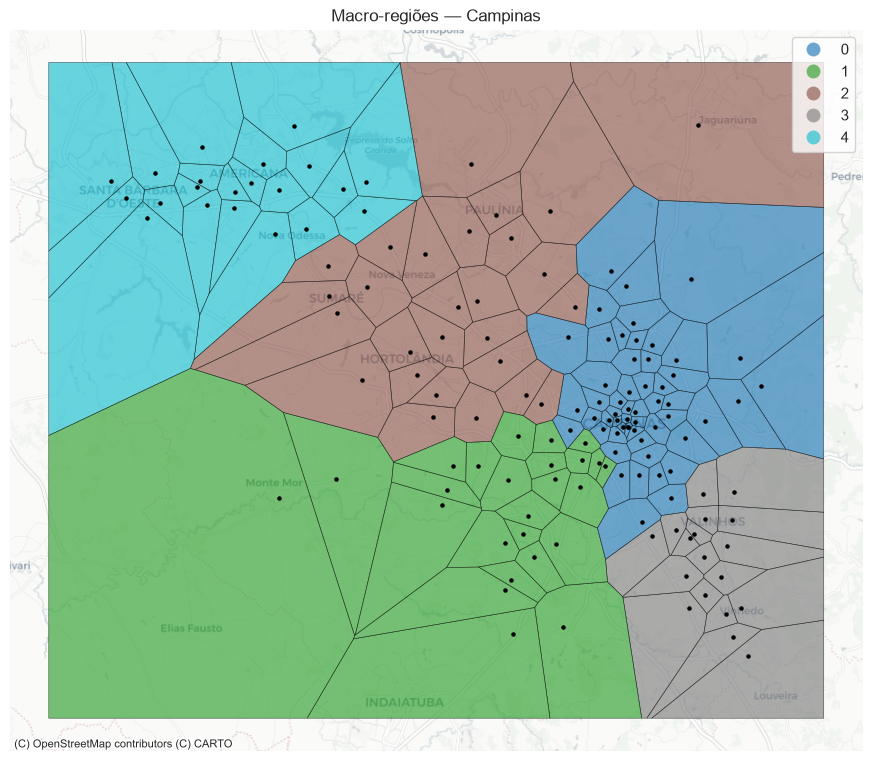

In [5]:
mapa("macro_region", "Macro-regiões — " + config["city_name"],
     cmap="tab10", categorico=True, dados=macro)

## 2. Distribuição de J entre pares conectados

A ordem de grandeza: quão conectadas duas regiões são, de fato?

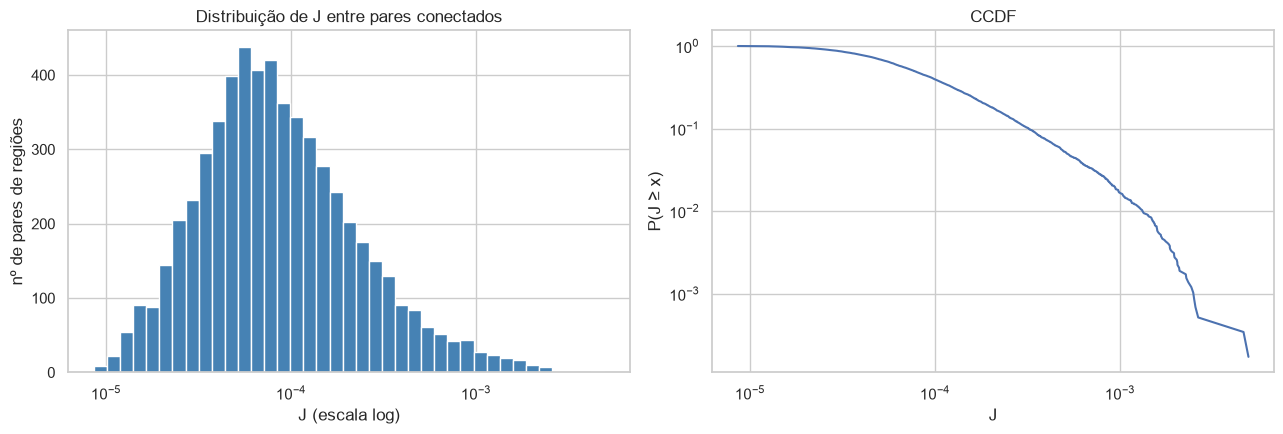

pares conectados: 5,817 de 10,440 possíveis (55.7%)
J: mediana 7.69e-05 | média 1.52e-04 | máximo 4.96e-03
o par mais denso conecta 0.50% dos seus pares possíveis


In [6]:
Jz = antenna.build_contact_matrix(edges_antenna, nodes, diagonal="zero").J
vals = Jz.to_numpy()[np.triu_indices(len(Jz), k=1)]
pos = vals[vals > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40), color="steelblue")
axes[0].set_xscale("log")
axes[0].set_xlabel("J (escala log)"); axes[0].set_ylabel("nº de pares de regiões")
axes[0].set_title("Distribuição de J entre pares conectados")

x = np.sort(pos)[::-1]
axes[1].loglog(x, np.arange(1, len(x) + 1) / len(x), "-")
axes[1].set_xlabel("J"); axes[1].set_ylabel("P(J ≥ x)")
axes[1].set_title("CCDF")
plt.tight_layout(); plt.show()

print(f"pares conectados: {len(pos):,} de {len(vals):,} possíveis ({len(pos)/len(vals):.1%})")
print(f"J: mediana {np.median(pos):.2e} | média {pos.mean():.2e} | máximo {pos.max():.2e}")
print(f"o par mais denso conecta {pos.max():.2%} dos seus pares possíveis")

Mais da metade dos pares de regiões tem **algum** contato, mas o mais denso liga menos de 1% dos
pares possíveis — as pessoas conhecem um punhado de gente, não bairros inteiros. A distribuição tem
cauda longa: a maioria dos pares se conecta muito pouco, alguns bem mais.

## 3. A matriz de J

Cada célula é o `J` entre duas regiões. As antenas estão agrupadas por macro-região, e as linhas
pretas marcam as fronteiras entre elas. A escala de cor é logarítmica porque J varre várias ordens
de grandeza.

Se a divisão em macro-regiões for real, os blocos ao longo da diagonal ficam visivelmente mais
escuros que o resto.

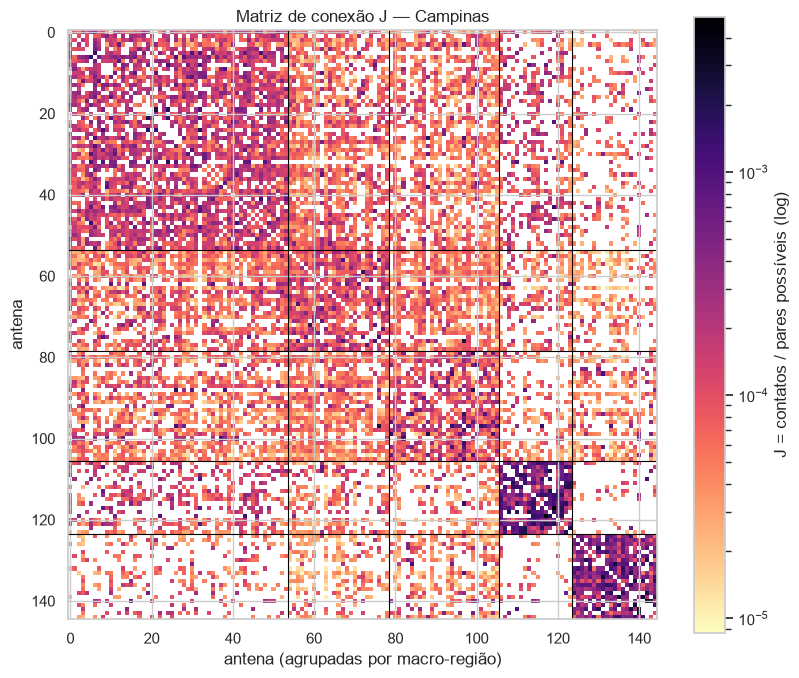

J médio dentro da mesma macro-região: 2.18e-04
J médio entre macro-regiões:          4.39e-05
razão: 5.0x


In [7]:
from matplotlib.colors import LogNorm

Jm = Jz.reindex(index=ordem, columns=ordem).to_numpy()
positivos = Jm[Jm > 0]

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(np.where(Jm > 0, Jm, np.nan), cmap="magma_r",
               norm=LogNorm(vmin=positivos.min(), vmax=positivos.max()), interpolation="nearest")
fig.colorbar(im, ax=ax, label="J = contatos / pares possíveis (log)")
for c in cortes:
    ax.axhline(c - 0.5, color="black", lw=0.8)
    ax.axvline(c - 0.5, color="black", lw=0.8)
ax.set_xlabel("antena (agrupadas por macro-região)"); ax.set_ylabel("antena")
ax.set_title("Matriz de conexão J — " + config["city_name"])
plt.show()

# quanto J é maior dentro da macro-região do que entre elas
mr = nodes.set_index("antenna_id")["macro_region"].reindex(ordem).to_numpy()
mesma = (mr[:, None] == mr[None, :]) & ~np.eye(len(Jm), dtype=bool)
print(f"J médio dentro da mesma macro-região: {Jm[mesma].mean():.2e}")
print(f"J médio entre macro-regiões:          {Jm[~mesma & ~np.eye(len(Jm),dtype=bool)].mean():.2e}")
print(f"razão: {Jm[mesma].mean() / Jm[~mesma & ~np.eye(len(Jm),dtype=bool)].mean():.1f}x")

## 4. A matriz de correlação — a outra leitura

Esta é a segunda forma de olhar a mesma matriz J, e ela responde a uma pergunta **diferente**.

### Duas perguntas distintas

Pegue a matriz J. Cada **linha** é o perfil de uma antena: com quem ela se conecta e com que
intensidade.

| Matriz | O valor na célula (l,m) é… | A pergunta que responde |
|---|---|---|
| **J** (seção 3) | a conexão direta entre l e m | *l e m falam entre si?* |
| **correlação** (esta) | a semelhança entre a linha de l e a linha de m | *l e m falam com as mesmas outras regiões?* |

Em análise de redes isso tem nomes: a primeira mede **coesão**, a segunda mede **equivalência
estrutural**.

### Por que a distinção importa

As duas podem discordar completamente. Imagine dois bairros-dormitório em pontas opostas da cidade,
ambos ligando muito para o centro e nunca um para o outro:

- **J entre eles ≈ 0** — não se falam.
- **correlação alta** — comportam-se de forma idêntica em relação ao resto da cidade.

São regiões que ocupam o **mesmo papel** na estrutura urbana, sem terem nenhuma relação direta. A
matriz J jamais mostraria isso.

### Como ler a escala

A correlação vai de **−1 a +1**, e não tem nada a ver com intensidade de conexão:

- **+1** — perfis idênticos: falam com as mesmas regiões, nas mesmas proporções.
- **0** — perfis sem relação.
- **−1** — perfis opostos: onde uma se conecta, a outra não.

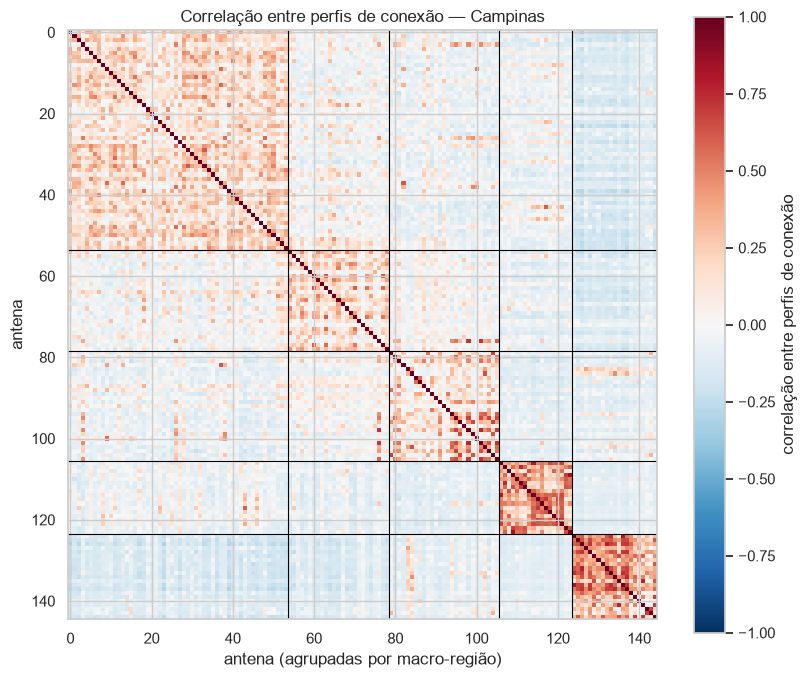

correlação: mediana -0.039 | mínima -0.315 | máxima +0.851
média dentro da mesma macro-região: +0.200
média entre macro-regiões distintas: -0.049


In [8]:
# perfis = linhas de J (sem a diagonal, que distorceria a correlação)
perfis = Jz.reindex(index=ordem, columns=ordem)
C = pd.DataFrame(np.corrcoef(perfis.to_numpy()), index=ordem, columns=ordem)

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(C.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
fig.colorbar(im, ax=ax, label="correlação entre perfis de conexão")
for c in cortes:
    ax.axhline(c - 0.5, color="black", lw=0.8)
    ax.axvline(c - 0.5, color="black", lw=0.8)
ax.set_xlabel("antena (agrupadas por macro-região)"); ax.set_ylabel("antena")
ax.set_title("Correlação entre perfis de conexão — " + config["city_name"])
plt.show()

fora = ~np.eye(len(C), dtype=bool)
mr = nodes.set_index("antenna_id")["macro_region"].reindex(ordem).to_numpy()
mesma_mr = (mr[:, None] == mr[None, :]) & fora
print(f"correlação: mediana {np.median(C.to_numpy()[fora]):+.3f} | "
      f"mínima {C.to_numpy()[fora].min():+.3f} | máxima {C.to_numpy()[fora].max():+.3f}")
print(f"média dentro da mesma macro-região: {C.to_numpy()[mesma_mr].mean():+.3f}")
print(f"média entre macro-regiões distintas: {C.to_numpy()[~mesma_mr & fora].mean():+.3f}")

### As duas matrizes lado a lado

Comparando célula a célula: as duas medidas concordam pouco. Se concordassem muito, uma delas seria
redundante.

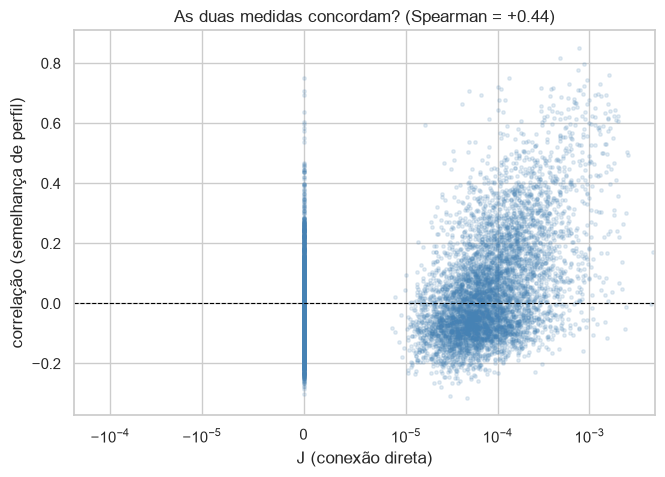

correlação de Spearman entre as duas medidas: +0.443


In [9]:
li, mi = np.triu_indices(len(ordem), k=1)
comp = pd.DataFrame({
    "a": ordem[li], "b": ordem[mi],
    "J": Jz.reindex(index=ordem, columns=ordem).to_numpy()[li, mi],
    "correlacao": C.to_numpy()[li, mi],
})
comp["mesma_macro"] = [macro[a] == macro[b] for a, b in zip(comp["a"], comp["b"])]

rho = comp[["J", "correlacao"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(comp["J"], comp["correlacao"], s=6, alpha=0.15, color="steelblue")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xscale("symlog", linthresh=1e-5)
ax.set_xlabel("J (conexão direta)"); ax.set_ylabel("correlação (semelhança de perfil)")
ax.set_title(f"As duas medidas concordam? (Spearman = {rho:+.2f})")
plt.show()

print(f"correlação de Spearman entre as duas medidas: {rho:+.3f}")

### Os casos que separam as duas medidas

**Equivalentes mas desconectadas** — nunca se falaram (`J = 0`), e ainda assim têm perfis muito
parecidos. São regiões com o mesmo papel na cidade. A matriz J as trata como estranhas.

In [10]:
comp.query("J == 0").nlargest(8, "correlacao").round(4)

,a,b,J,correlacao,mesma_macro
9740,835,3608,0.0,0.7493,True
10006,5476,6458,0.0,0.7090,True
10437,7344,7362,0.0,0.6926,True
9778,2282,4685,0.0,0.6370,True
10255,405,4399,0.0,0.6031,True
5362,6361,6458,0.0,0.5984,False
9784,2282,7842,0.0,0.5858,True
9847,3211,4685,0.0,0.5747,True


**Conectadas mas diferentes** — falam bastante entre si, mas o resto do comportamento delas não tem
nada a ver. Tipicamente uma região pequena grudada numa vizinha grande: a pequena depende da grande,
a grande se relaciona com a cidade inteira.

In [11]:
fortes = comp.nlargest(300, "J")
fortes.nsmallest(8, "correlacao").round(4)

,a,b,J,correlacao,mesma_macro
1446,1432,4691,0.0009,-0.1595,False
9330,5867,5550,0.0015,-0.1164,False
2179,2085,6837,0.0007,-0.1066,False
9808,2282,7362,0.0005,-0.1059,False
9876,3211,7344,0.0011,-0.1052,False
10202,8309,6312,0.0006,-0.0972,False
2155,2085,5550,0.0005,-0.0881,False
8114,7999,5867,0.0024,-0.0851,False


### Resumo

| | matriz de J | matriz de correlação |
|---|---|---|
| Escala | 0 a 1 (na prática, ≤ 0,005) | −1 a +1 |
| Mede | conexão direta | semelhança de comportamento |
| Conceito | coesão | equivalência estrutural |
| Duas regiões que nunca se falam | valor 0 | pode ser +0,8 |
| Serve para | encontrar corredores, comunidades | encontrar papéis parecidos |

Nenhuma substitui a outra. Para a apresentação, a matriz de **J** é a mais direta ("estes bairros
conversam"); a de **correlação** é a que permite dizer "estes bairros, mesmo distantes e sem contato
entre si, funcionam do mesmo jeito".

## 5. Agrupamento hierárquico

### O que ele faz

Em vez de devolver uma divisão pronta, ele constrói uma **árvore**. Começa com cada antena sozinha e,
repetidamente, funde as duas mais próximas — até sobrar um grupo só. O desenho dessa sequência é o
**dendrograma**: a altura de cada junção é a distância em que as duas partes se uniram.

### O que é "distância" aqui

Precisamos transformar J (uma *semelhança*: quanto maior, mais conectadas) numa *distância*
(quanto maior, mais separadas). Usamos:

```
d(l,m) = log( J_máximo / J(l,m) )
```

Ou seja: **quantas ordens de grandeza abaixo do par mais forte da cidade**. O par mais conectado
tem distância 0; pares sem nenhum contato ficam com a distância máxima.

### Para que serve, se já temos o Louvain

Três coisas que a partição plana não dá:

1. **A hierarquia.** O Louvain devolve 5 grupos e ponto. A árvore mostra o aninhamento — quais
   grupos se fundem cedo (são quase um só) e quais só no topo. Dá para escolher o número de grupos
   *depois* de ver a estrutura, em vez de aceitar o que o algoritmo decidiu.
2. **Outliers.** O Louvain é obrigado a colocar toda antena em algum grupo. A árvore pode deixar uma
   antena pendurada numa altura alta, sinalizando "esta não se parece com nenhuma".
3. **Uma segunda opinião.** É um algoritmo com lógica completamente diferente — não otimiza
   modularidade. Quando os dois concordam, a divisão é mais confiável.

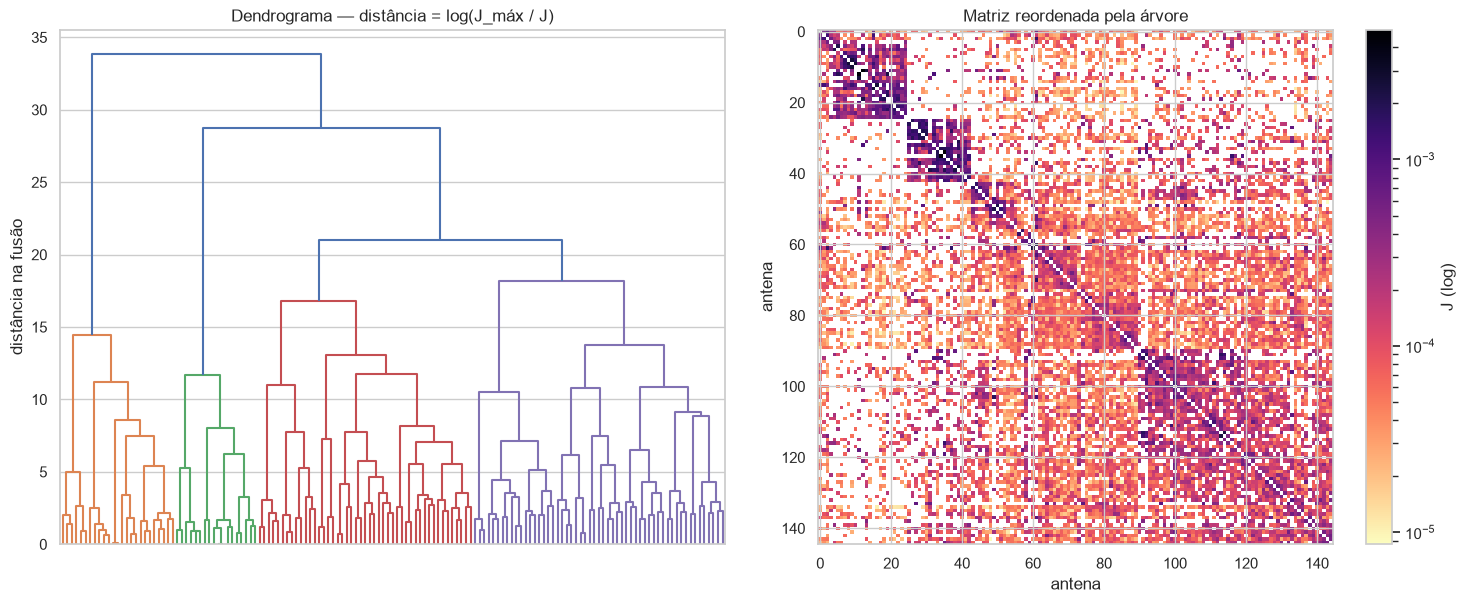

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

Jv = Jz.reindex(index=ordem, columns=ordem).to_numpy()
menor = Jv[Jv > 0].min()
Dist = np.log(Jv.max() / np.where(Jv > 0, Jv, menor / 10))   # pares sem contato: distância máxima
np.fill_diagonal(Dist, 0.0)
Dist = (Dist + Dist.T) / 2                                    # simetria exata

Z = linkage(squareform(Dist, checks=False), method="ward")
ordem_h = ordem[dendrogram(Z, no_plot=True)["leaves"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=0.55 * max(Z[:, 2]))
axes[0].set_title("Dendrograma — distância = log(J_máx / J)")
axes[0].set_ylabel("distância na fusão")

Jh = Jz.reindex(index=ordem_h, columns=ordem_h).to_numpy()
im = axes[1].imshow(np.where(Jh > 0, Jh, np.nan), cmap="magma_r",
                    norm=LogNorm(vmin=positivos.min(), vmax=positivos.max()), interpolation="nearest")
fig.colorbar(im, ax=axes[1], label="J (log)")
axes[1].set_title("Matriz reordenada pela árvore")
axes[1].set_xlabel("antena"); axes[1].set_ylabel("antena")
plt.tight_layout(); plt.show()

No dendrograma, um corte horizontal a uma dada altura define uma partição. Quanto mais alto o corte,
menos grupos. A tabela abaixo compara cada corte com a divisão do Louvain usando o **ARI** (Adjusted
Rand Index): 1 significa partições idênticas, 0 significa concordância no nível do acaso.

In [13]:
def ari(a, b):
    """Adjusted Rand Index (sem sklearn)."""
    ct = pd.crosstab(a, b).to_numpy()
    c2 = lambda n: n * (n - 1) / 2
    idx, sa, sb, n = c2(ct).sum(), c2(ct.sum(1)).sum(), c2(ct.sum(0)).sum(), c2(ct.sum())
    esp = sa * sb / n
    return (idx - esp) / ((sa + sb) / 2 - esp)


for k in [3, 4, 5, 6, 7]:
    g = pd.Series(fcluster(Z, k, criterion="maxclust"), index=ordem).sort_index()
    print(f"k={k}: ARI com o Louvain = {ari(g, macro.sort_index()):+.3f} | "
          f"tamanhos {sorted(g.value_counts().tolist(), reverse=True)}")

k=3: ARI com o Louvain = +0.384 | tamanhos [102, 25, 18]
k=4: ARI com o Louvain = +0.632 | tamanhos [55, 47, 25, 18]
k=5: ARI com o Louvain = +0.475 | tamanhos [47, 37, 25, 18, 18]
k=6: ARI com o Louvain = +0.494 | tamanhos [37, 34, 25, 18, 18, 13]
k=7: ARI com o Louvain = +0.496 | tamanhos [37, 34, 19, 18, 18, 13, 6]


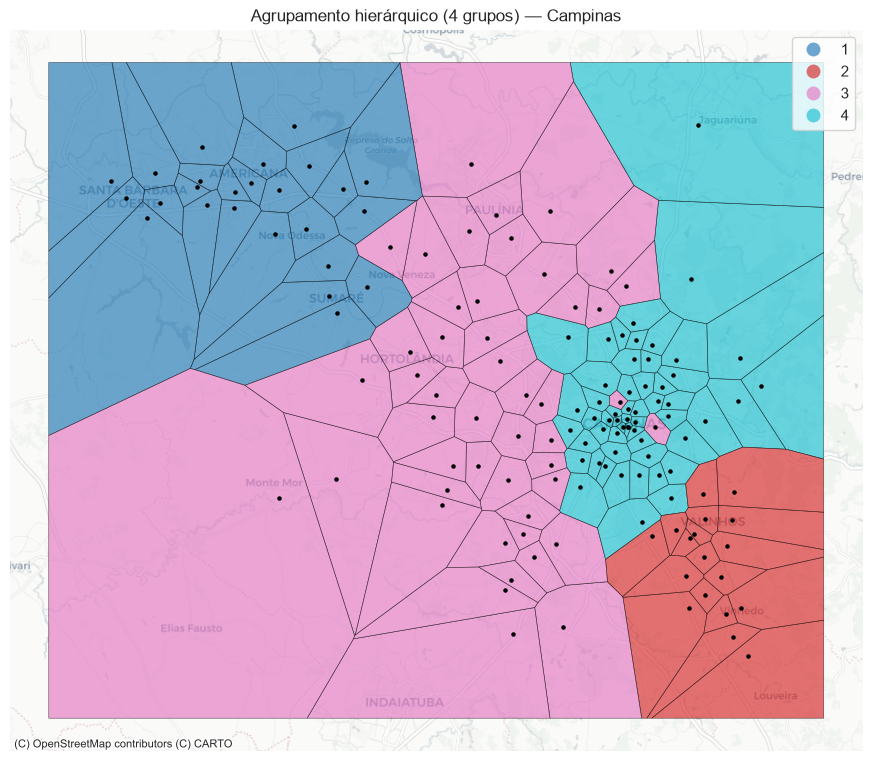

In [14]:
hier4 = pd.Series(fcluster(Z, 4, criterion="maxclust"), index=ordem).sort_index()
mapa("grupo_hier", "Agrupamento hierárquico (4 grupos) — " + config["city_name"],
     cmap="tab10", categorico=True, dados=hier4)

**Leitura honesta deste resultado.** A concordância com o Louvain é moderada (ARI ~0,6 no melhor
corte), não alta. Duas razões:

- Agrupar **direto sobre J** usa o mesmo critério do Louvain — "quem fala com quem" — então os dois
  competem no mesmo terreno, e as diferenças são só de método, não de perspectiva.
- J é muito assimétrico; poucos pares fortes dominam as primeiras fusões.

Agrupar pela **matriz de correlação** da seção 4 dava concordância bem maior (ARI 0,85), justamente
porque ali o critério é outro — semelhança de perfil, não conexão direta. Duas medidas independentes
concordando valem mais como validação do que duas versões do mesmo critério.

## 6. J cai com a distância?

Como J já é normalizado pelo tamanho das regiões, dá para olhar o decaimento direto — sem precisar
de um modelo de gravidade para separar o efeito de população.

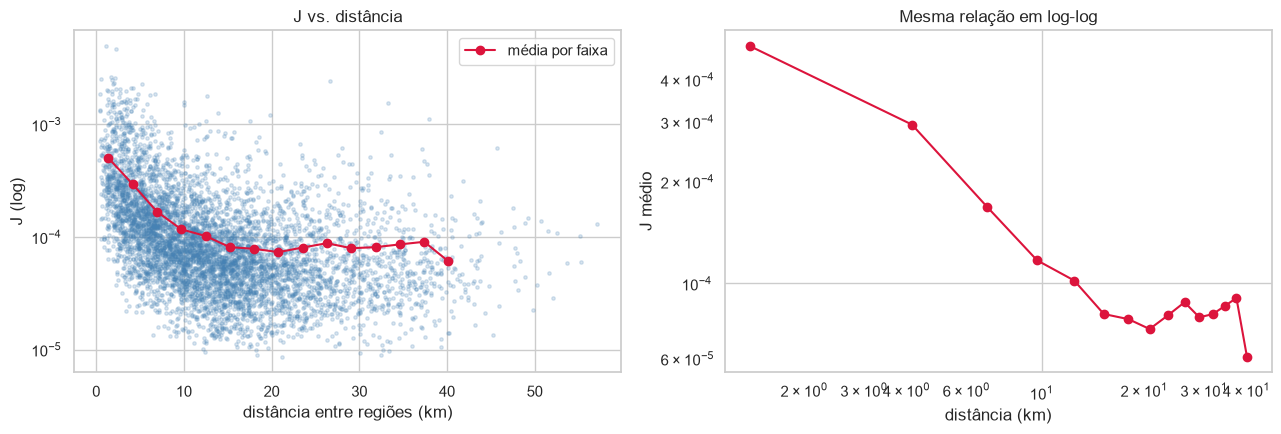

ajuste direto: J ~ d^-0.67


In [15]:
f = flows[flows["J"] > 0].copy()
faixas = pd.cut(f["dist_km"], bins=np.linspace(0, f["dist_km"].quantile(0.99), 16))
por_faixa = f.groupby(faixas, observed=True).agg(J=("J", "mean"), n=("J", "size")).reset_index()
por_faixa["dist"] = por_faixa["dist_km"].apply(lambda i: i.mid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(f["dist_km"], f["J"], s=6, alpha=0.2, color="steelblue")
axes[0].plot(por_faixa["dist"], por_faixa["J"], "o-", color="crimson", label="média por faixa")
axes[0].set_yscale("log")
axes[0].set_xlabel("distância entre regiões (km)"); axes[0].set_ylabel("J (log)")
axes[0].set_title("J vs. distância"); axes[0].legend()

axes[1].loglog(por_faixa["dist"], por_faixa["J"], "o-", color="crimson")
axes[1].set_xlabel("distância (km)"); axes[1].set_ylabel("J médio")
axes[1].set_title("Mesma relação em log-log")
plt.tight_layout(); plt.show()

ok = f["dist_km"] > 0
b, _ = np.polyfit(np.log(f.loc[ok, "dist_km"]), np.log(f.loc[ok, "J"]), 1)
print(f"ajuste direto: J ~ d^{b:.2f}")

## 7. J entre os quintis

`J` médio para cada par de quintis. Como J já é normalizado por tamanho, responde direto: *duas
regiões de estratos diferentes se conectam menos do que duas do mesmo estrato?*

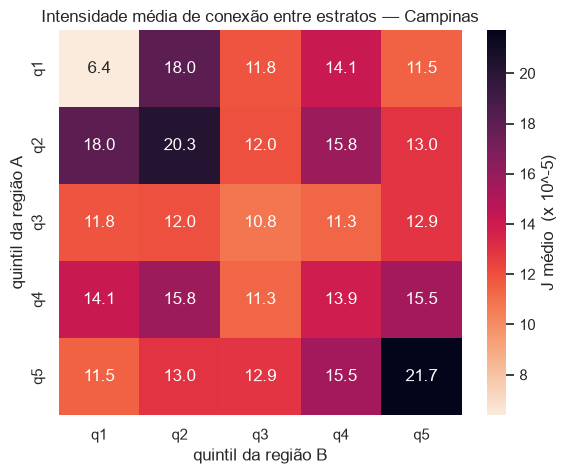

J médio dentro do mesmo quintil: 1.46e-04
J médio entre quintis distintos: 1.36e-04
razão: 1.08x


In [16]:
QUINTIS = ["q1", "q2", "q3", "q4", "q5"]
q = nodes.set_index("antenna_id")["residence_quintile_state"]

par = flows.copy()
par["qa"] = par["a"].map(q); par["qb"] = par["b"].map(q)
longo = pd.concat([par[["qa", "qb", "J"]],
                   par[["qb", "qa", "J"]].rename(columns={"qb": "qa", "qa": "qb"})])
M = longo.pivot_table(index="qa", columns="qb", values="J", aggfunc="mean").reindex(
    index=QUINTIS, columns=QUINTIS)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(M * 1e5, annot=True, fmt=".1f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "J médio  (x 10^-5)"})
ax.set_xlabel("quintil da região B"); ax.set_ylabel("quintil da região A")
ax.set_title("Intensidade média de conexão entre estratos — " + config["city_name"])
plt.show()

diag = np.diagonal(M.to_numpy())
fora_d = M.to_numpy()[~np.eye(5, dtype=bool)]
print(f"J médio dentro do mesmo quintil: {np.nanmean(diag):.2e}")
print(f"J médio entre quintis distintos: {np.nanmean(fora_d):.2e}")
print(f"razão: {np.nanmean(diag)/np.nanmean(fora_d):.2f}x")

## 8. Conectividade de cada região, no mapa

### O que está sendo somado

Cada linha da matriz J tem 144 valores: o `J` daquela região com cada uma das outras. Somando a
linha inteira, temos a **conectividade total da região** — quão densamente ela se liga ao resto da
cidade, já descontado o tamanho.

### Por que isso não é o mesmo que "região movimentada"

Volume de chamadas mede quanto se fala; `J` mede **que fração dos laços possíveis existe**. Uma
região grande e movimentada pode ter J baixo: muita gente, muitas chamadas, mas cada morador
conhece só um punhado de pessoas de cada outra região.

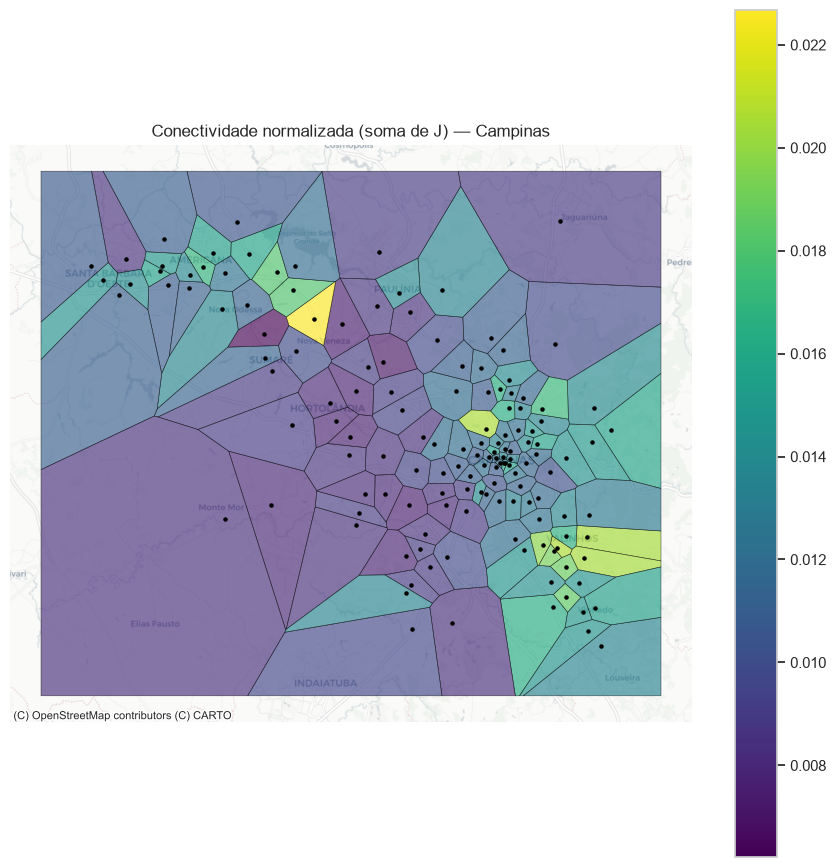

correlação de Spearman:
             forca_J  calls_total  n_users
forca_J        1.000       -0.479   -0.587
calls_total   -0.479        1.000    0.943
n_users       -0.587        0.943    1.000


In [17]:
forca_J = Jz.sum(axis=1).rename("forca_J")
nodes["forca_J"] = nodes["antenna_id"].map(forca_J)

mapa("forca_J", "Conectividade normalizada (soma de J) — " + config["city_name"],
     cmap="viridis", dados=forca_J)

print("correlação de Spearman:")
print(nodes[["forca_J", "calls_total", "n_users"]].corr(method="spearman").round(3).to_string())

### O problema deste mapa

A correlação com o tamanho da região é **negativa e forte** (≈ −0,59). Ou seja, o mapa está
mostrando, em boa parte, **onde as regiões são pequenas** — e isso é um artefato da métrica, não um
fato sobre a cidade.

A razão é aritmética. Cada pessoa mantém um número limitado de contatos, então o numerador `K`
cresce mais ou menos **linearmente** com a população. Já o denominador `u_l · u_m` cresce ao
**quadrado**. Resultado: J cai com o tamanho por construção. É o mesmo motivo pelo qual a densidade
de qualquer rede cai conforme ela cresce, se o grau por nó é limitado.

### O que fazer com isso

- **Para comparar um par de regiões**, J está correto — é para isso que o artigo o define, e o
  denominador `u_l · u_m` é exatamente o número de laços possíveis entre aquelas duas populações.
- **Para comparar regiões entre si**, somar a linha de J não serve. Uma normalização **linear**
  (contatos por morador, `Σ_m K_lm / u_l`) fica muito mais perto de neutra em relação ao tamanho.

Leia este mapa, então, como *"onde os laços são densos em relação ao tamanho"* — e não como
*"quais regiões são mais conectadas"*.